# Backpropagation from Scratch — MNIST

Goal: implement a neural network with **only NumPy** — no PyTorch, no sklearn — and train it to classify handwritten digits.

Network: `784 → 30 → 10` (input pixels → hidden layer → one output per digit), sigmoid activations, quadratic cost, mini-batch SGD.

**The four backprop equations** (Nielsen, ch. 2):

1. Output error: $\delta^L = (a^L - y) \odot \sigma'(z^L)$
2. Backpropagate: $\delta^l = ((w^{l+1})^T \delta^{l+1}) \odot \sigma'(z^l)$
3. Bias gradient: $\partial C/\partial b^l = \delta^l$
4. Weight gradient: $\partial C/\partial w^l = \delta^l (a^{l-1})^T$


## 1. Load MNIST

The pickle in `0-mnist/` was made with Python 2, so we need `encoding='latin1'`.

In [1]:
import gzip
import itertools
import pickle

import matplotlib.pyplot as plt
import numpy as np

with gzip.open("../data/mnist.pkl.gz", "rb") as f:
    train_set, valid_set, test_set = pickle.load(f, encoding="latin1")

print(
    "train:",
    train_set[0].shape,
    "| validation:",
    valid_set[0].shape,
    "| test:",
    test_set[0].shape,
)

train: (50000, 784) | validation: (10000, 784) | test: (10000, 784)


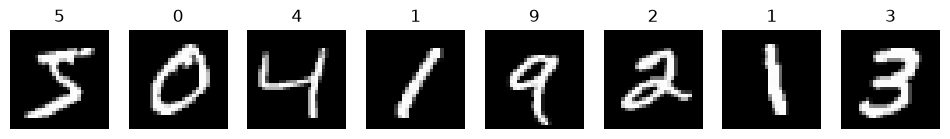

In [2]:
# Each image is a flat vector of 784 pixels (28x28), values in [0, 1]
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, label in zip(axes, train_set[0][:8], train_set[1][:8]):
    ax.imshow(img.reshape(28, 28), cmap="gray")
    ax.set_title(label)
    ax.axis("off")
plt.show()

## 2. Reshape the data

We work with column vectors: input `x` is `(784, 1)`, target `y` is a one-hot `(10, 1)` vector (e.g. digit 3 → `[0,0,0,1,0,0,0,0,0,0]`).

In [3]:
def one_hot(j):
    y = np.zeros((10, 1))
    y[j] = 1.0
    return y


training_data = [(x.reshape(784, 1), one_hot(y)) for x, y in zip(*train_set)]
test_data = [
    (x.reshape(784, 1), y) for x, y in zip(*test_set)
]  # keep label as int for scoring

print(len(training_data), "training samples,", len(test_data), "test samples")

50000 training samples, 10000 test samples


## 3. Sigmoid and its derivative

$\sigma(z) = \frac{1}{1 + e^{-z}}$ squashes any number into (0, 1). Its derivative $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ is what lets gradients flow backward.

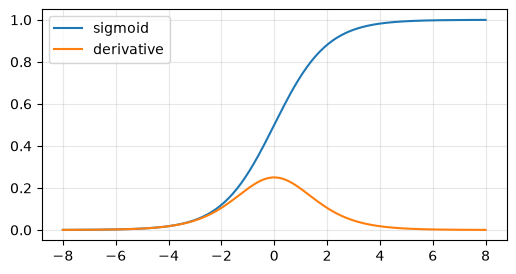

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1 - s)


z = np.linspace(-8, 8, 200)
plt.figure(figsize=(6, 3))
plt.plot(z, sigmoid(z), label="sigmoid")
plt.plot(z, sigmoid_prime(z), label="derivative")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Initialize the network

- `weights[0]` is `(30, 784)`: connects input → hidden
- `weights[1]` is `(10, 30)`: connects hidden → output
- biases: one per neuron in each non-input layer

Random init breaks symmetry — if all weights started equal, every neuron would learn the same thing.

In [9]:
sizes = [784, 30, 10]
rng = np.random.default_rng(42)

biases = [rng.standard_normal((n, 1)) for n in sizes[1:]]
weights = [rng.standard_normal((n, m)) for m, n in itertools.pairwise(sizes)]

for i, (w, b) in enumerate(zip(weights, biases)):
    print(f"layer {i + 1}: weights {w.shape}, biases {b.shape}")

layer 1: weights (30, 784), biases (30, 1)
layer 2: weights (10, 30), biases (10, 1)


## 5. Feedforward

Each layer computes $z = wa + b$, then $a = \sigma(z)$. The final activation is the network's prediction: 10 numbers, the largest one is the guessed digit.

In [ ]:
def feedforward(a):
    for w, b in zip(weights, biases):
        a = sigmoid(w @ a + b)
    return a


x, y = training_data[0]
out = feedforward(x)
print("output:", out.ravel().round(3))
print("predicted digit:", np.argmax(out), "| true digit:", np.argmax(y))
# Untrained network -> prediction is essentially random

output: [0.999 0.832 0.762 0.006 0.999 0.999 0.96  0.603 0.997 0.997]
predicted digit: 5 | true digit: 5


## 6. Backpropagation — the heart of it

One sample in, gradients out. Two passes:

- **Forward**: compute and *store* every `z` and activation `a` (we need them going back).
- **Backward**: start from the output error (eq. 1), walk layers in reverse (eq. 2), collecting gradients (eqs. 3, 4).

In [ ]:
def backprop(x, y):
    """Return (nabla_w, nabla_b): gradients of the cost for one sample."""
    # --- forward pass: store all z's and activations ---
    activation = x
    activations = [x]  # a^0, a^1, ..., a^L
    zs = []  # z^1, ..., z^L
    for w, b in zip(weights, biases):
        z = w @ activation + b
        zs.append(z)
        activation = sigmoid(z)
        activations.append(activation)

    nabla_w = [np.zeros(w.shape) for w in weights]
    nabla_b = [np.zeros(b.shape) for b in biases]

    # --- backward pass ---
    # Eq 1: output error (quadratic cost: dC/da = a - y)
    delta = (activations[-1] - y) * sigmoid_prime(zs[-1])
    nabla_b[-1] = delta  # Eq 3
    nabla_w[-1] = delta @ activations[-2].T  # Eq 4

    # Eq 2: propagate the error backward through hidden layers
    for l in range(2, len(sizes)):
        delta = (weights[-l + 1].T @ delta) * sigmoid_prime(zs[-l])
        nabla_b[-l] = delta
        nabla_w[-l] = delta @ activations[-l - 1].T
    return nabla_w, nabla_b


nw, nb = backprop(*training_data[0])
print("gradient shapes:", [g.shape for g in nw], [g.shape for g in nb])

### Sanity check: compare against numerical gradients

The gold-standard debugging trick — nudge one weight by a tiny $\epsilon$ and check $\frac{C(w+\epsilon) - C(w-\epsilon)}{2\epsilon}$ matches what backprop computed.

In [ ]:
def cost(x, y):
    return 0.5 * np.sum((feedforward(x) - y) ** 2)


x, y = training_data[0]
nw, _ = backprop(x, y)

eps = 1e-5
for i, j in [(0, 10), (5, 20), (9, 17)]:
    orig = weights[1][i, j]
    weights[1][i, j] = orig + eps
    c_plus = cost(x, y)
    weights[1][i, j] = orig - eps
    c_minus = cost(x, y)
    weights[1][i, j] = orig
    numeric = (c_plus - c_minus) / (2 * eps)
    print(f"w[1][{i},{j}]  backprop: {nw[1][i, j]: .8f}   numeric: {numeric: .8f}")

## 7. Mini-batch stochastic gradient descent

Average gradients over a small batch, then step downhill: $w \leftarrow w - \frac{\eta}{m} \sum \nabla w$.

In [ ]:
def update_mini_batch(batch, eta):
    global weights, biases
    sum_nw = [np.zeros(w.shape) for w in weights]
    sum_nb = [np.zeros(b.shape) for b in biases]
    for x, y in batch:
        nw, nb = backprop(x, y)
        sum_nw = [a + d for a, d in zip(sum_nw, nw)]
        sum_nb = [a + d for a, d in zip(sum_nb, nb)]
    weights = [w - (eta / len(batch)) * g for w, g in zip(weights, sum_nw)]
    biases = [b - (eta / len(batch)) * g for b, g in zip(biases, sum_nb)]


def evaluate(data):
    return sum(int(np.argmax(feedforward(x)) == y) for x, y in data)

In [ ]:
import random

epochs, batch_size, eta = 10, 10, 3.0
history = []

for epoch in range(1, epochs + 1):
    random.shuffle(training_data)
    for k in range(0, len(training_data), batch_size):
        update_mini_batch(training_data[k : k + batch_size], eta)
    correct = evaluate(test_data)
    history.append(correct / len(test_data))
    print(
        f"epoch {epoch:2d}: {correct} / {len(test_data)} correct ({100 * history[-1]:.2f}%)"
    )

In [ ]:
plt.figure(figsize=(6, 3))
plt.plot(range(1, len(history) + 1), history, marker="o")
plt.xlabel("epoch")
plt.ylabel("test accuracy")
plt.grid(alpha=0.3)
plt.title("Learning curve")
plt.show()

## 8. Look at what it gets wrong

In [ ]:
wrong = [
    (x, y, np.argmax(feedforward(x)))
    for x, y in test_data
    if np.argmax(feedforward(x)) != y
]
print(len(wrong), "mistakes out of", len(test_data))

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, (x, true, pred) in zip(axes, wrong[:8]):
    ax.imshow(x.reshape(28, 28), cmap="gray")
    ax.set_title(f"{true}\u2192{pred}")
    ax.axis("off")
plt.show()

## Exercises (try these next)

1. **Cross-entropy cost**: replace the quadratic cost — the output error simplifies to `delta = a - y` (no `sigmoid_prime`!) and learning speeds up. Why?
2. **Better init**: divide weights by `np.sqrt(fan_in)` and watch early epochs improve.
3. **Bigger hidden layer**: try 100 neurons. Accuracy vs. training time?
4. **Vectorize the batch**: process a whole mini-batch as one matrix instead of looping sample-by-sample (~10x faster).
5. Rebuild the same network in PyTorch and confirm `loss.backward()` gives the same gradients as your `backprop()`.